# Species Diffusion | Text-to-Image Inference

Now we have arrived at the last step of the project. If you are here, you should have a dataset of images and generated k-means JSON files containing prompts.
The main aim of this notebook is to generate images from prompts using Stable Diffusion, to imagine the machine's interpretation of endurance borrowing the form of more-than-human intelligences.

Notebook based on Jérémie Wenger as one of the module contects from Data and Machine Learning at Goldsmiths.

## Step 1 - Install python models
Run this if you don't have the models installed on your machine.

In [ ]:
!pip install diffusers transformers accelerate

## Step 2 - Import models and set up the device

If you need to load/save to your drive:

In [ ]:

from google.colab import drive
drive.mount("/content/drive/")

I usually have been choosing GPU from Google Colab.  
After setting up Goole Colab on vscode, by running this code, you can check which GPU model you are using.

In [ ]:
!nvidia-smi


### Imports

In [ ]:
# load the model and scheduler
import torch
import json
from pathlib import Path
from diffusers import StableDiffusionPipeline

# Step 3 — set up the device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")


## Step 3 - Load the prompts from clusters

### The key points of the clusters

There were particularly interesting clusters identified. There are a total of 10 species groups. I was curious about what would happen if the number of clusters differed from, or matched, the number of species groups. To test this, I ran the clustering code with 9, 10, and 4 clusters respectively, and the results were shown below.

##### UMAP K=9
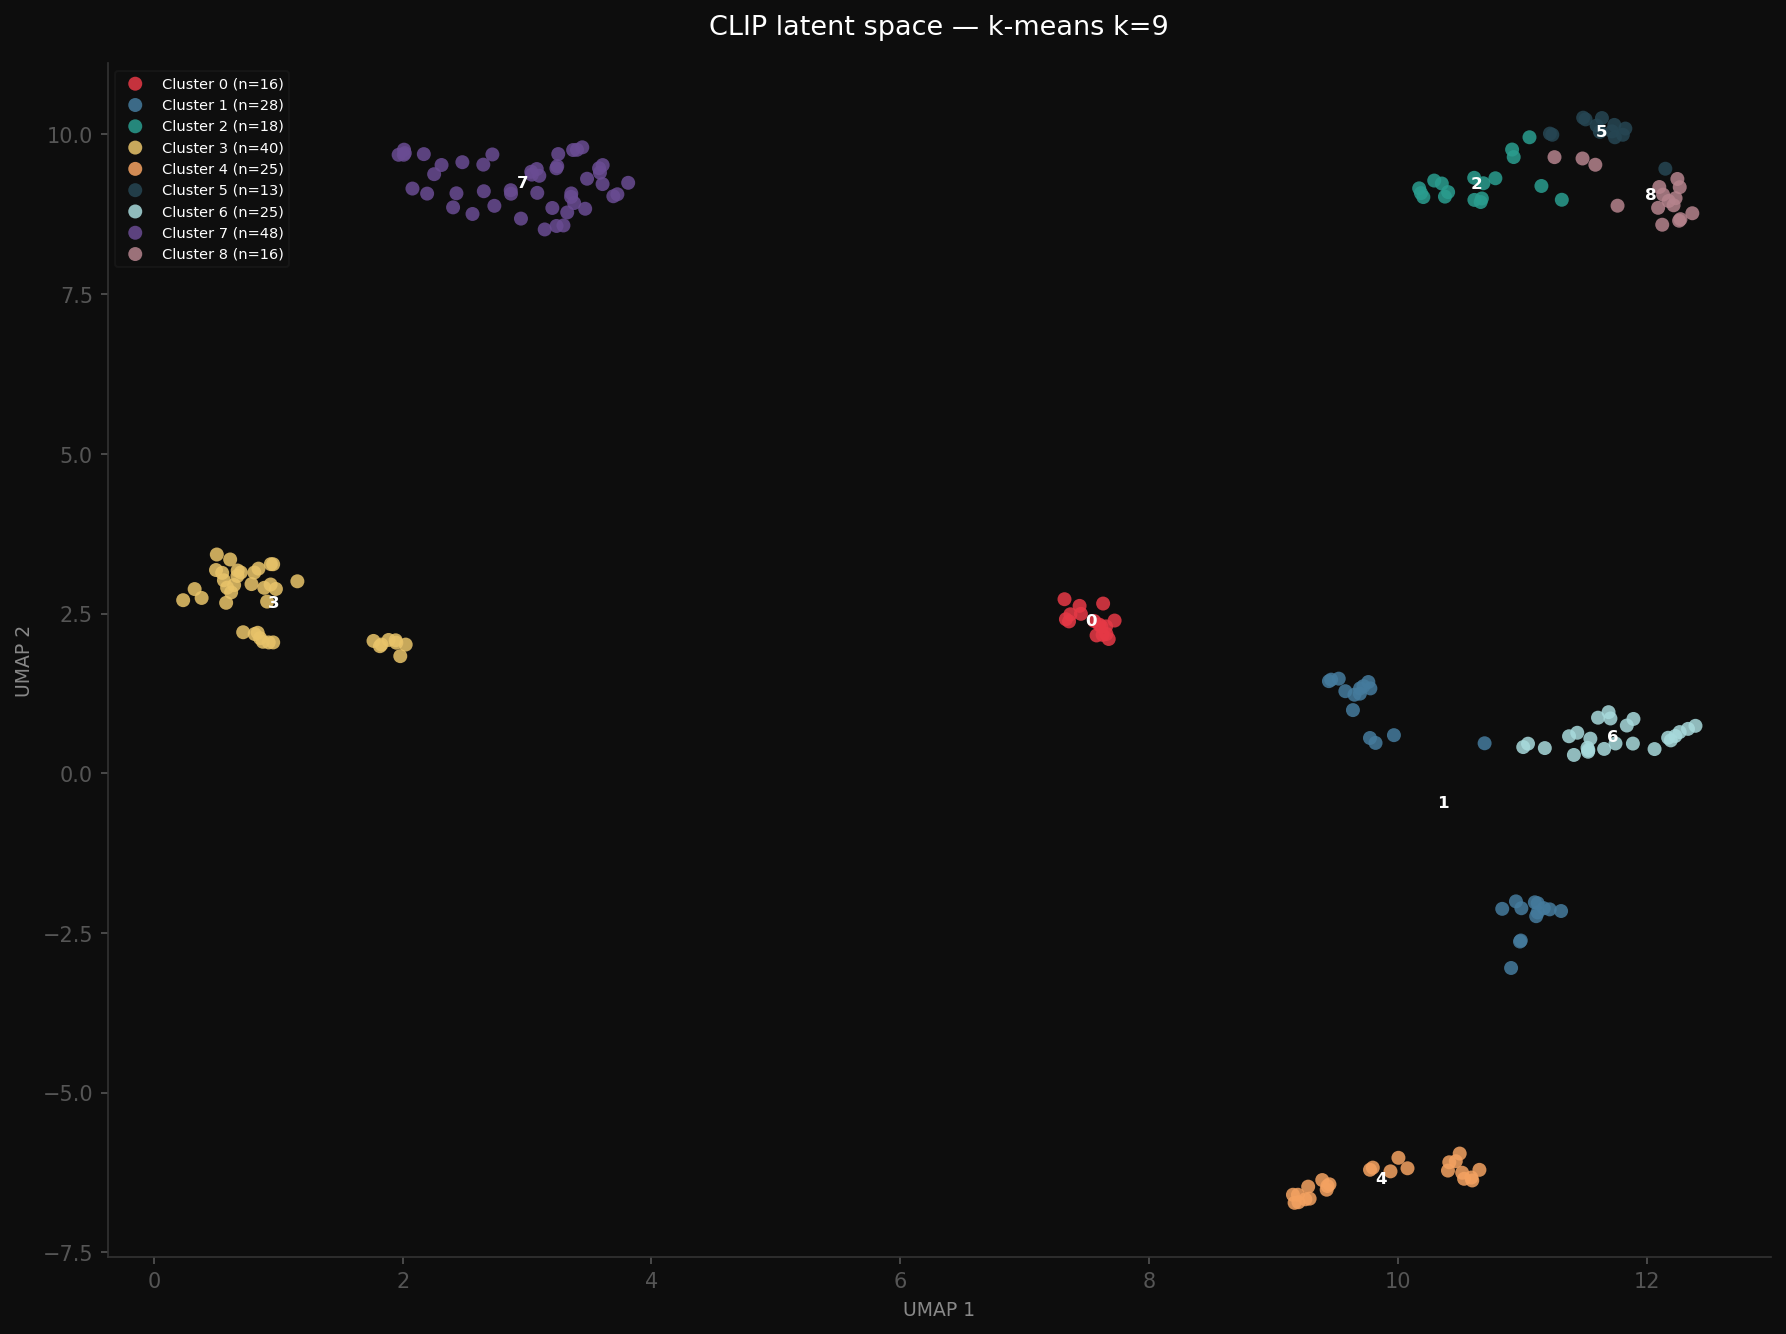

##### UMAP K=10
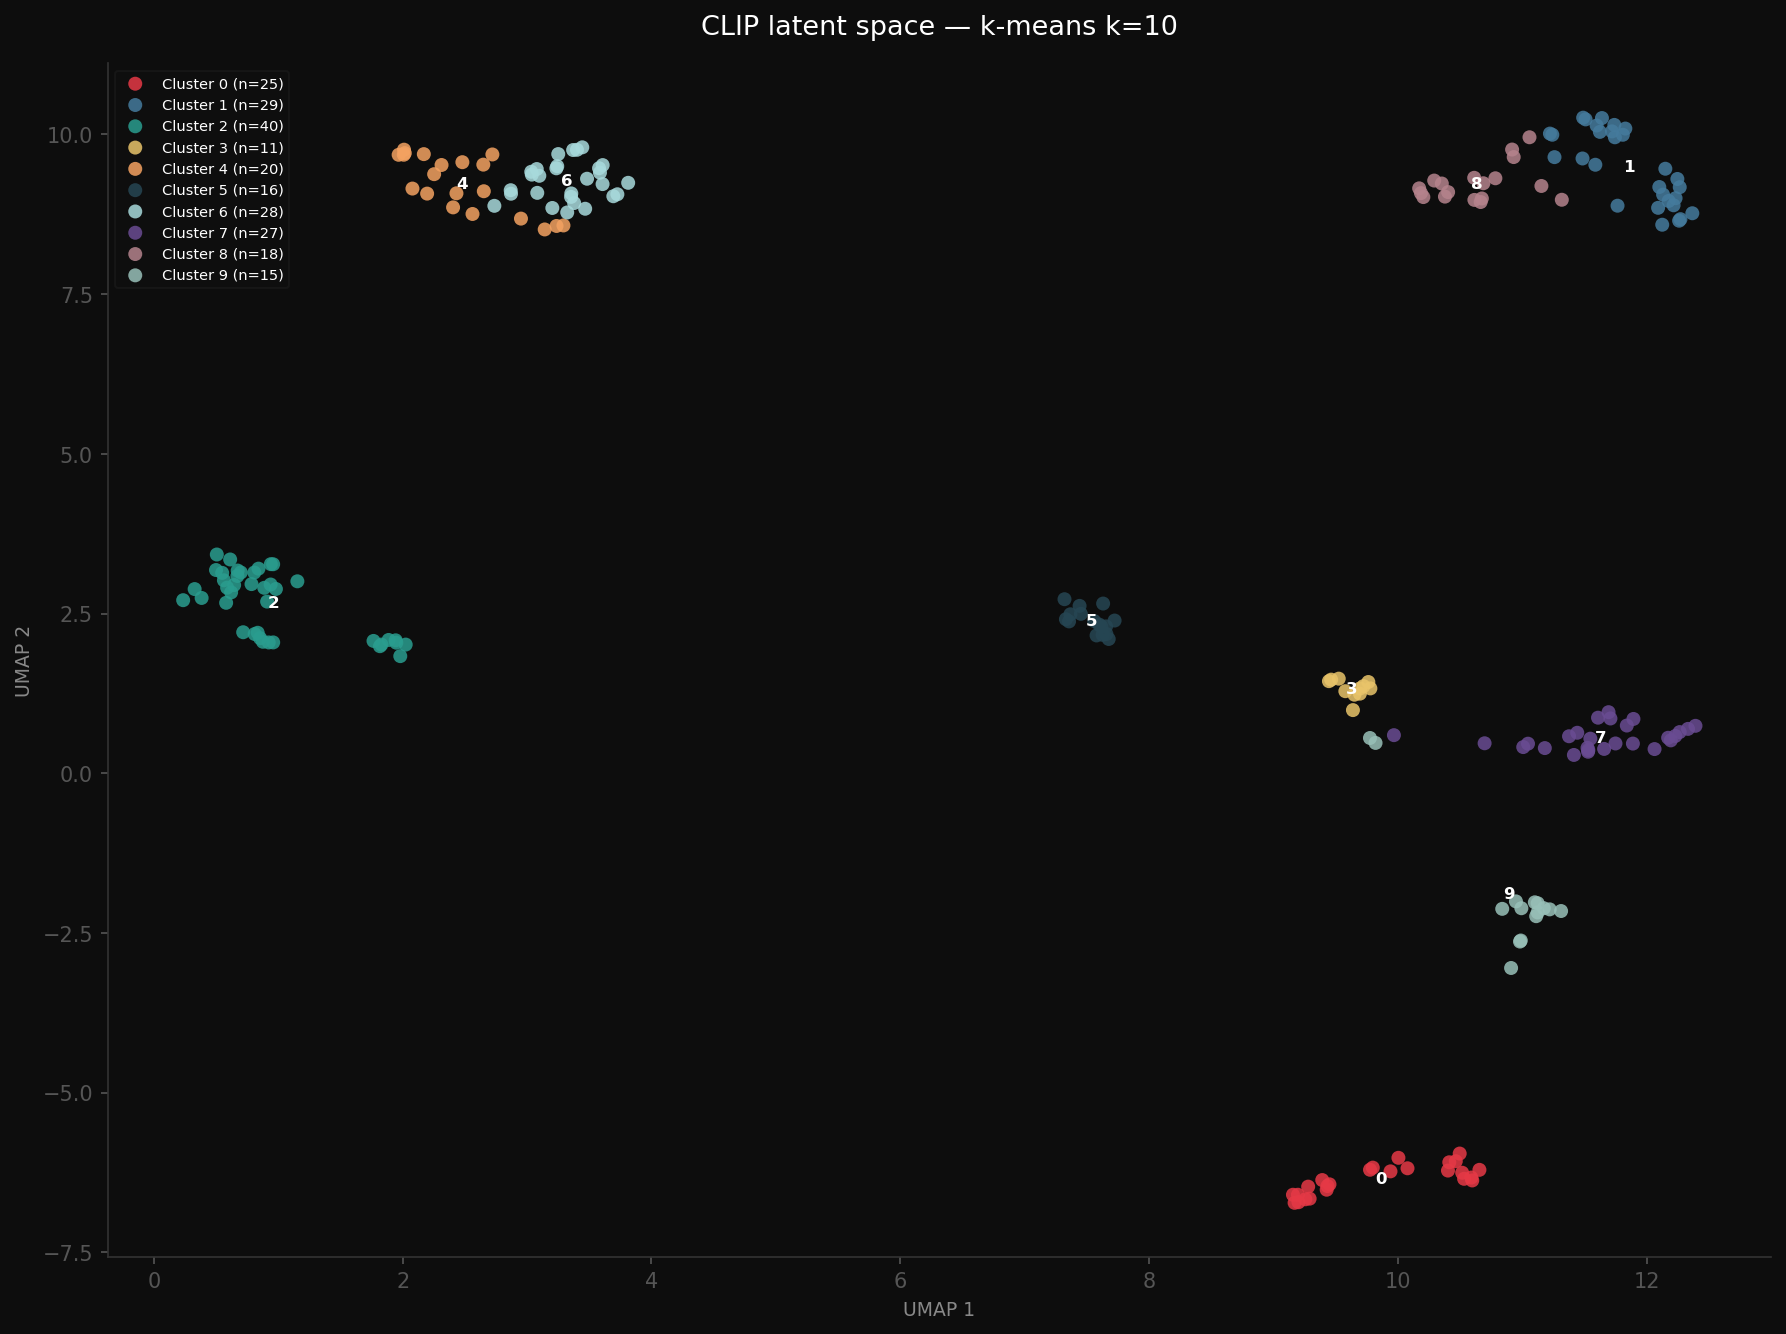

##### UMAP K=4
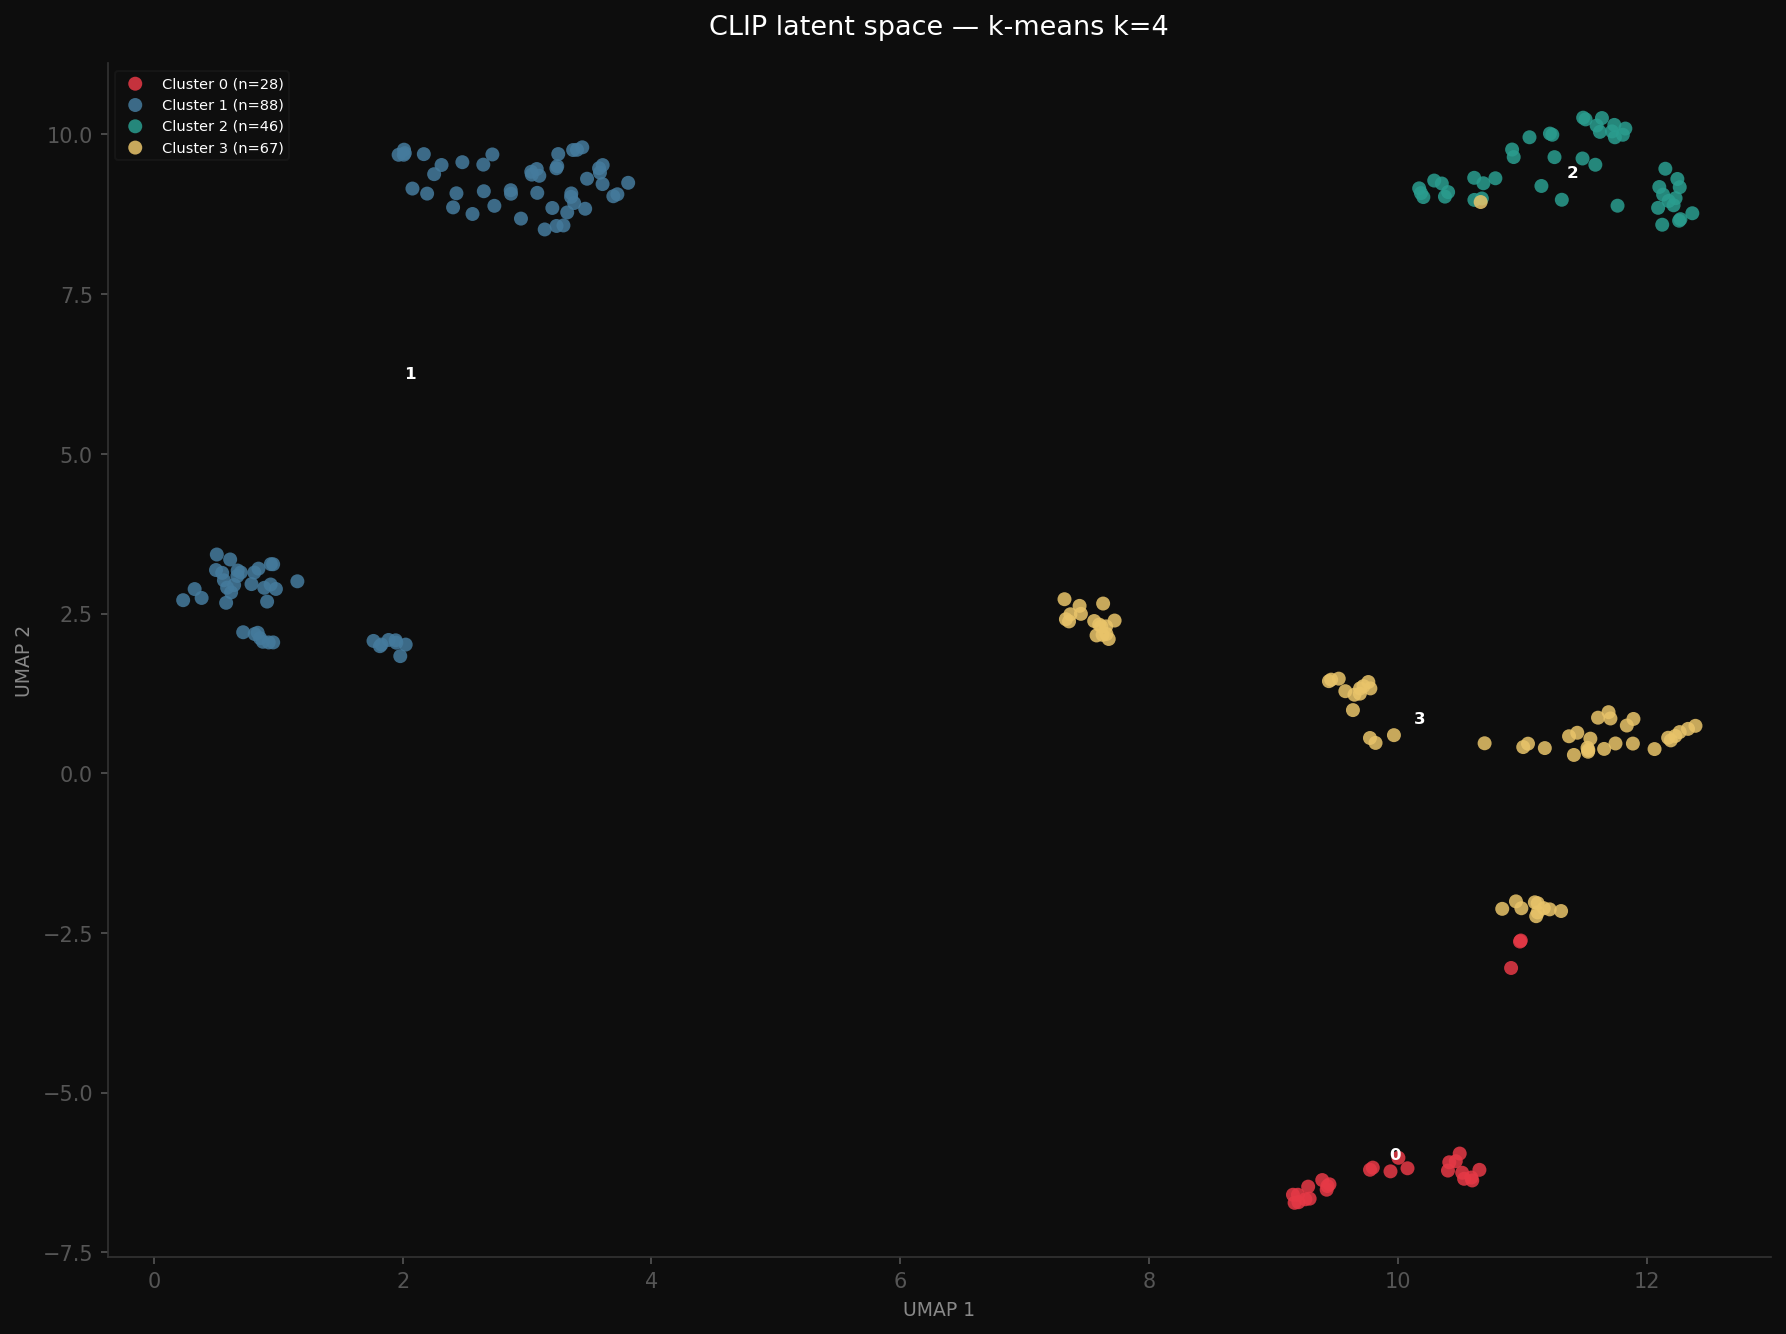

### Conceptual Findings

The UMAP visualisation reveals that the latent space splits into two separate worlds. The left side contains specimen and field photographs; the right side contains SEM microscopy images. There is almost no overlap between them. The large empty space in the middle is not nothing. It is the machine telling me that the distance between a photograph of a crocodile and an electron microscope image of a tardigrade is, to CLIP, one of the largest distances in my entire dataset.

What this means is that the machine organised my dataset primarily by how organisms were imaged, not what they are. Scale, instrument, lighting, and visual register dominate the geometry before any biological information gets encoded. My four conceptual categories (Evolutionary Continuity, Extream Resilience, Longevity, Persistence) partially separate, but the separation is confounded by image register. Persistence and longevity cluster together partly because both are dominated by specimen photography against neutral backgrounds. Resilience clusters separately partly because it is represented entirely through SEM microscopy. The machine first learns how organisms were seen before it learns what it means to exist beyond human time.

##### SEM Cluster

The SEM cluster contains tardigrade and stromatolites sitting near each other across both k=9 and k=10 results. A microscopic animal that survives through cryptobiosis, and a geological record of cyanobacterial mats 3.5 billion years old. The machine grouped them not because they share biology, but because they share a visual world: microscopic, structural, grey, isolated against dark backgrounds. This accidental grouping reveals that the machine found a relationship between organisms that human taxonomy would never connect, and the relationship it found is about how they appear when examined at a scale beyond human perception. This is arguably a deep time property in itself.

##### Cluster 1: Convergence of Resilience and Geological Time

Tardigrade + stromatolites + cyanobacteria, purity 0.48, marked mixed, convergence of resilience and longevity. From the k=10 results, this is the cluster that cuts most dramatically across my conceptual categories. A microscopic indestructible animal grouped with a 3.5 billion year geological record. The machine found a connection between biological extremophilia and geological time inscription that my taxonomy never named. This is the prompt I consider most worth taking into image generation. It describes a speculative organism that is simultaneously indestructible and ancient, existing at a scale and timescale entirely beyond human perception.

##### Cluster 8: Deep Sea and Microscopic

Glass sponge + cyanobacteria + stromatolites + tardigrade, purity 0.67, all SEM microscopy. This cluster groups an organism that lives 10,000 years on the deep ocean floor with microscopic photosynthetic life and a microscopic extremophile. Biologically these have nothing in common. What the machine found connecting them is a shared visual world: isolated structural forms against dark backgrounds, rendered at a scale invisible to the naked eye. The glass sponge's silica lattice and the tardigrade's cuticle surface share a visual geometry of complex structure against darkness that CLIP encodes as proximity. Longevity and resilience collapsed into a single visual register. The speculative organism suggested by this cluster would be one whose survival is expressed entirely through structural geometry, a body plan that is itself the evidence of endurance.

##### Cluster 9: The Boundary Cluster

Nautilus + stromatolites + crocodile + horseshoe crab, purity 0.47, mixed. This is the same boundary cluster that appears in both k=9 and k=10 results. The machine keeps finding this grouping regardless of how many clusters it is asked to make. That persistence across different k values means it is a real structural feature of the latent space, not a statistical artifact. These four species share something CLIP detects consistently: hard external structures including shell, carapace, calcified layers, and scaled skin. The machine may be encoding mineralised armour as a deep time survival feature, grouping organisms whose body plan has functioned as protection across geological epochs. The speculative organism this cluster suggests would be one that survives by becoming structure, an externalised skeleton that persists long after the living tissue within it has gone.

##### Across k=4, k=9, and k=10

Three findings remain consistent regardless of how many clusters the machine was asked to find. First, the SEM and specimen photography boundary is absolute. The machine never places a microscopy image alongside a field photograph regardless of species. Second, crocodile is always the most isolated species, forming its own cluster or nearly so in every run. Its visual distinctiveness and its biological uniqueness appear to be the same thing. Third, the boundary cluster mixing nautilus, horseshoe crab, stromatolites, and crocodile reappears in every configuration. These persistent structures suggest the machine has found real geometry in the latent space, not noise, but something it consistently detects about the visual character of deep time survival. The gap between my four conceptual categories and the machine's own organisation of this space was not the same, and I find it interesting.

### Load the prompts
Now, upload the text prompts generated by k-means clustering by running commands from the previous step.  
For example, if you have done the k-means clustering of 10 cluster groups, you should have files named: 
- clusters_k10.json
- prompts_k10.json

If you haven't already, try run:  
`python3 cluster_and_extract.py --k 10`

If you want to skip the json creation steps, you can also download json from [here](https://drive.google.com/drive/folders/1QdQtb5_vkHCJUElwlKICh6vI215eMzjX?usp=sharing), then save it into corresponded Google Drive path. 

And set the cluster type to get the prompts to generate images:

In [ ]:
# Manage cluster types and target clusters
generatingClusterType = "k10"  # Change this each run: 'k4', 'k9', 'k10'

In [ ]:
# Access the json file at its Drive path. Make sure you have put the json files in here.
with open(f"/content/drive/MyDrive/DeepTime/prompts_{generatingClusterType}.json") as f:
    prompts_data = json.load(f)

print(f"Loaded {len(prompts_data)} clusters from {generatingClusterType}")

# Print what I get
for p in prompts_data:
    print(f"\nCluster {p['cluster_id']} — {p['dominant_species']}")
    print(f"  Mixed: {p['is_mixed_cluster']}, Purity: {p['purity']}")
    print(f"  Short prompt: {p['prompt_short'][:80]}...")


### Pipiline

I use [StableDiffusionPipeline](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5), as it is known as a good balance of quality and speed on Colab T4.

In [ ]:
# Using SD 1.5 — good balance of quality and speed on Colab T4
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, safety_checker=None
).to(device)

Considering the analysis about k-means clustering suggested above, image generation can be proceed as following:

In [ ]:
# Set variables for generation
isSaveFiles = False  # Set to True to save generated images to Drive, False to keep in Colab (will be lost after session ends)
isIgnoreMixedClusters = False  # Set to True to skip mixed clusters, False to include them
clusters_to_generate = [1, 8, 9]  # Only generate for these cluster IDs

# Negative prompt consistent across all generations
negative_prompt = (
    "photorealistic, photograph, natural environment, "
    "colourful, cartoon, illustration, text, watermark, "
    "blurry, low quality, logo, "
    "human, face, person, "
)

# Target the three mixed clusters identified in analysis
# These clusters have the highest diversity and lowest purity, making them ideal for creative generation
target_clusters = [
    p for p in prompts_data if (p["is_mixed_cluster"] and not isIgnoreMixedClusters) or p["cluster_id"] in clusters_to_generate
]

if isSaveFiles is True:
    Path(f"/content/drive/MyDrive/DeepTime/generated/{generatingClusterType}").mkdir(
        parents=True, exist_ok=True
    )
else:
    Path(f"generated/{generatingClusterType}").mkdir(exist_ok=True)

# Generate images for each target cluster with multiple seeds for variety
for cluster in target_clusters:
    cluster_id = cluster["cluster_id"]
    prompt = cluster["prompt_short"]

    print(f"\nGenerating cluster {cluster_id}...")
    print(f"  {prompt[:100]}...")

    # Generate 3 variations per cluster with different seeds
    for seed in [42, 137, 512]: # Chosen for variety and to avoid common "lucky" seeds - feel free to experiment!!
        generator = torch.Generator(device=device).manual_seed(seed)

        image = pipe(
            prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=30,
            guidance_scale=8.5,  # higher = closer to prompt, good for abstract
            generator=generator,
            height=512,
            width=512,
        ).images[0]

        if isSaveFiles:
            filename = f"/content/drive/MyDrive/DeepTime/generated/{generatingClusterType}/cluster_{cluster_id}_seed{seed}.png"
        else:
            filename = f"generated/{generatingClusterType}/cluster_{cluster_id}_seed{seed}.png"

        image.save(filename)
        print(f"  Saved: {filename}")
        display(image)


#### Notes

If you couldn't generate images because you have a problem for any reason, you can view the generated images as an example from [Google Drive](https://drive.google.com/drive/folders/12ru7Bp1q4SJOik6_ghnRzpfTvR0E7O1l?usp=sharing).